## CNN - Convolutional Neural Networks

This is a brief overview of Convolutional Neural Networks (CNNs), which are a class of deep learning models commonly used for image recognition and processing tasks.

In [121]:
import numpy as np
import keras 
from keras.datasets import mnist
from keras.models import Model
from keras.layers import Dense, Input
from keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten
import pandas as pd

In [101]:
np.random.seed(42)

In [102]:
# Load the MNIST dataset
(x_train , y_train) , (x_test , y_test) = mnist.load_data()

Text(0.5, 1.0, 'Distribution of Classes in MNIST Dataset')

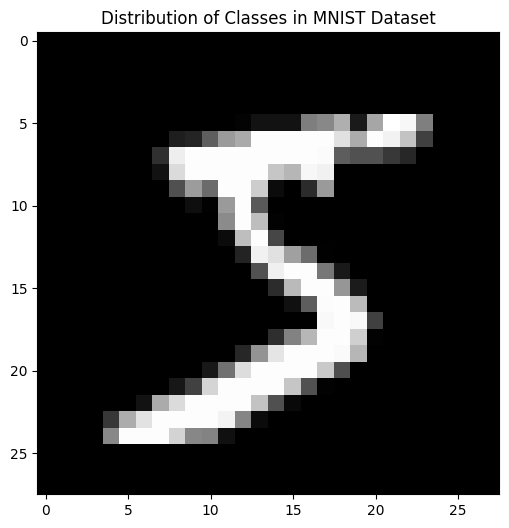

In [103]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
plt.imshow(x_train[0], cmap='gray')
plt.title('Distribution of Classes in MNIST Dataset')

In [104]:
x_test.shape

(10000, 28, 28)

In [105]:
# Changing the Shape of the data for CNN
x_train_reshaped = x_train.reshape(60000, 28, 28, 1)
x_test_reshaped = x_test.reshape(10000, 28, 28, 1)

In [119]:
# Z score normalization of the data
x_train_normalized = x_train_reshaped.astype('float32') / 255.0
x_test_normalized = x_test_reshaped.astype('float32') / 255.0

In [107]:
# Categorical encoding of the labels
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder()

y_train_cat = encoder.fit_transform(y_train.reshape(-1, 1))
y_test_cat = encoder.transform(y_test.reshape(-1, 1))

In [108]:
y_train[0:10]

array([5, 0, 4, 1, 9, 2, 1, 3, 1, 4], dtype=uint8)

In [135]:
y_train_cat_array = y_train_cat.toarray()
y_test_cat_array = y_test_cat.toarray()

In [136]:
inpx = Input(shape=(28, 28, 1))
layer1 = Conv2D(32, kernel_size=(3, 3), activation='relu')(inpx)
layer2 = Conv2D(64, (3, 3), activation='relu')(layer1)
layer3 = MaxPooling2D(pool_size=(3, 3))(layer2)
layer4 = Dropout(0.5)(layer3)
layer5 = Flatten()(layer4)
layer6 = Dense(250, activation='sigmoid')(layer5)
layer7 = Dense(10, activation='softmax')(layer6)

In [138]:
model = Model([inpx], layer7)
model.compile(optimizer=keras.optimizers.Adam(),
              loss=keras.losses.categorical_crossentropy,
              metrics=['accuracy'])

model.fit(x_train_reshaped, y_train_cat_array, epochs=12, batch_size=500)

Epoch 1/12
120/120 ━━━━━━━━━━━━━━━━━━━━ 21s 166ms/step - accuracy: 0.8965 - loss: 0.3747
Epoch 2/12
120/120 ━━━━━━━━━━━━━━━━━━━━ 23s 189ms/step - accuracy: 0.9729 - loss: 0.0972
Epoch 3/12
120/120 ━━━━━━━━━━━━━━━━━━━━ 21s 175ms/step - accuracy: 0.9798 - loss: 0.0702
Epoch 4/12
120/120 ━━━━━━━━━━━━━━━━━━━━ 20s 165ms/step - accuracy: 0.9842 - loss: 0.0565
Epoch 5/12
120/120 ━━━━━━━━━━━━━━━━━━━━ 21s 174ms/step - accuracy: 0.9862 - loss: 0.0479
Epoch 6/12
120/120 ━━━━━━━━━━━━━━━━━━━━ 22s 183ms/step - accuracy: 0.9877 - loss: 0.0422
Epoch 7/12
120/120 ━━━━━━━━━━━━━━━━━━━━ 20s 169ms/step - accuracy: 0.9891 - loss: 0.0386
Epoch 8/12
120/120 ━━━━━━━━━━━━━━━━━━━━ 20s 170ms/step - accuracy: 0.9904 - loss: 0.0339
Epoch 9/12
120/120 ━━━━━━━━━━━━━━━━━━━━ 22s 179ms/step - accuracy: 0.9909 - loss: 0.0310
Epoch 10/12
120/120 ━━━━━━━━━━━━━━━━━━━━ 21s 174ms/step - accuracy: 0.9915 - loss: 0.0292
Epoch 11/12
120/120 ━━━━━━━━━━━━━━━━━━━━ 20s 165ms/step - accuracy: 0.9919 - loss: 0.0281
Epoch 12/12
120/120

In [139]:
output = model.evaluate(x_test_reshaped, y_test_cat_array)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9915 - loss: 0.0264


In [140]:
o = model.predict(x_test_reshaped[0:10]).argmax(axis=1)
o

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


array([7, 2, 1, 0, 4, 1, 4, 9, 5, 9])

In [141]:
y_test[0:10]

array([7, 2, 1, 0, 4, 1, 4, 9, 5, 9], dtype=uint8)

In [142]:
## Using college's way

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Dropout, Flatten
from tensorflow.keras.datasets import mnist

In [ ]:
## If I go by Input layer
from tensorflow.keras.layers import Input

In [143]:
(x_train , y_train) , (x_test , y_test) = mnist.load_data()

In [177]:
model = Sequential([
    #Input(shape=(28,28,1)),
    Conv2D(32 , kernel_size=(3,3) , activation='relu' , input_shape=(28,28,1) , padding='same'),
    MaxPooling2D((2,2)),
    Conv2D(64 , kernel_size=(3,3) , activation='relu' , padding='same'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(250 , activation='sigmoid'),
    Dense(10 , activation='softmax')
])

In [178]:
model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_26 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_13 (Flatten)            │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 250)            │       784,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 10)             │         2,510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 805,576 (3.07 MB)

 Trainable params: 805,576 (3.07 MB)

 Non-trainable params: 0 (0.00 B)

In [182]:
model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(),
    optimizer=keras.optimizers.Adam(),
    metrics=[keras.metrics.SparseCategoricalAccuracy()]
)

model.fit(x_train_reshaped, y_train, epochs=10, batch_size=128)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 24s 37ms/step - loss: 0.2049 - sparse_categorical_accuracy: 0.9529
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - loss: 0.0475 - sparse_categorical_accuracy: 0.9877
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - loss: 0.0363 - sparse_categorical_accuracy: 0.9901
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - loss: 0.0276 - sparse_categorical_accuracy: 0.9924
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - loss: 0.0235 - sparse_categorical_accuracy: 0.9934
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - loss: 0.0199 - sparse_categorical_accuracy: 0.9947
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - loss: 0.0179 - sparse_categorical_accuracy: 0.9950
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - loss: 0.0153 - sparse_categorical_accuracy: 0.9958
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - loss: 0.0153 - sparse_categorical_accuracy: 0.9955
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━

In [188]:
pred_probs = model.predict(x_test_reshaped)
pred_labels = pred_probs.argmax(axis=1)
pred_labels[:10]


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


array([7, 2, 1, 0, 4, 1, 4, 9, 5, 9])

In [189]:
y_test[0:10]

array([7, 2, 1, 0, 4, 1, 4, 9, 5, 9], dtype=uint8)